# Vectorized QMC

Demonstrates QMC integration with vectorized (batched) function evaluation.

Original QMCPy demo: [`QMCPy/demos/vectorized_qmc.ipynb`](../../QMCPy/demos/vectorized_qmc.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QuasiMC.jl/blob/develop/demos/vectorized_qmc.ipynb)

*This Julia notebook keeps the QMCPy `LD Sequence`, `Simple Example`, Bayesian logistic-regression, and sensitivity-oriented vectorized integration material in one place. The QMCPy `BO QEI` section maps to [`qei_demo.ipynb`](qei_demo.ipynb), the Ishigami sensitivity example maps to [`sensitivity_indices.ipynb`](sensitivity_indices.ipynb), and the machine-learning sensitivity story maps to [`iris.ipynb`](iris.ipynb).*

Parity note: this Julia notebook keeps the overlapping vectorized-integration and Bayesian logistic-regression sections from QMCPy in one place, labels `Output Distribution` as a Julia extension, maps `BO QEI` to [`qei_demo.ipynb`](qei_demo.ipynb), Ishigami sensitivity to [`sensitivity_indices.ipynb`](sensitivity_indices.ipynb), and machine-learning sensitivity to [`iris.ipynb`](iris.ipynb). The logistic-regression calculation uses a Laplace-centered QMC proposal to avoid underflow in the direct prior-sampling ratio estimator.


In [1]:
using QuasiMC
using LinearAlgebra: Diagonal
import QuasiMC: Uniform
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## LD Sequence

Compare IID, digital net, and lattice point sets.

In [2]:
n = 2^6
for (dd, name) in [
    (IIDStdUniform(2; seed=7),  "IID"),
    (DigitalNetB2(2; seed=7, t=63, order="RADICAL INVERSE"), "Digital Net"),
    (Lattice(2; seed=7),        "Lattice"),
]
    pts = gen_samples(dd, n)
    println("$name: $(size(pts, 1)) points, " *
            "mean=$(round.(mean(pts, dims=1), digits=3))")
end

IID: 64 points, mean=[0.506 0.422]


Digital Net: 64 points, mean=[0.502 0.5]


Lattice: 64 points, mean=[0.507 0.499]


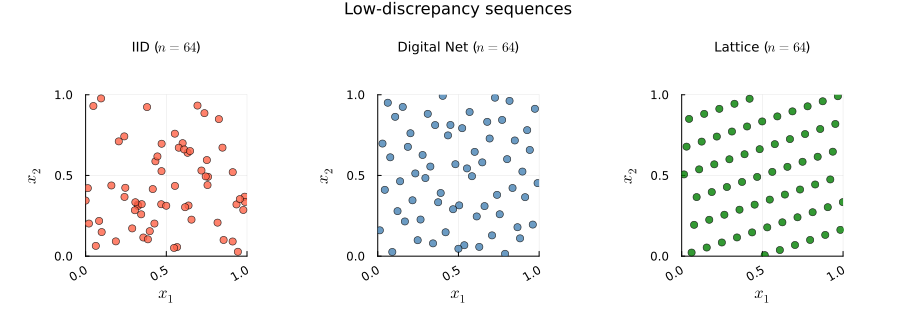

In [3]:
if HAVE_PLOTS
    n_s = 2^6
    sampler_specs = [
        ("IID",         IIDStdUniform(2; seed=7),  :tomato),
        ("Digital Net", DigitalNetB2(2; seed=7, t=63, order="RADICAL INVERSE"), :steelblue),
        ("Lattice",     Lattice(2; seed=7),         :green),
    ]
    scatter_plts = []
    for (name, dd, col) in sampler_specs
        pts = gen_samples(dd, n_s)
        local p = scatter(pts[:, 1], pts[:, 2];
            markersize=4, alpha=0.8, color=col, label=nothing,
            xlabel="\$x_1\$", ylabel="\$x_2\$",
            title="$name (\$n=$n_s\$)",
            xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal,
            xticks=[0, 0.5, 1], yticks=[0, 0.5, 1], xrotation=30,
            left_margin=2Plots.mm, right_margin=2Plots.mm)
        push!(scatter_plts, p)
    end
    display(plot(scatter_plts...; layout=(1, 3), size=(900, 320),
        plot_titlevspan=0.12, plot_title="Low-discrepancy sequences",
        top_margin=10Plots.mm, bottom_margin=8Plots.mm))
end


## Simple Example

The cantilever beam function maps 3-dimensional input to a 2-component output (displacement and stress). QuasiMC.jl naturally handles batched evaluation of such vector-valued outputs.

In [4]:
# Cantilever beam: (E, X, Y) → (displacement D, stress S)
function cantilever_beam(x)
    l, w, t = 100.0, 4.0, 2.0
    E, X, Y = x[1], x[2], x[3]
    D = 4l^3 / (E * w * t) * sqrt(X^2 / t^4 + Y^2 / w^4)
    S = 600 * (X / (w * t^2) + Y / (w^2 * t))
    return [D, S]
end

# Match the QMCPy example: Gaussian input model for (E, X, Y)
dd = DigitalNetB2(3; seed=7, graycode=false)
tm = Gaussian(dd;
    mean=[2.9e7, 500.0, 1000.0],
    covariance=Diagonal([(1.45e6)^2, (100.0)^2, (100.0)^2]))
u = gen_samples(dd, 1024)
x = transform(tm, u)

results = hcat([cantilever_beam(x[i, :]) for i in 1:size(x, 1)]...)
println("Displacement: mean=$(round(mean(results[1,:]), digits=4)), " *
        "std=$(round(std(results[1,:]), digits=4))")
println("Stress:       mean=$(round(mean(results[2,:]), digits=4)), " *
        "std=$(round(std(results[2,:]), digits=4))")

Displacement: mean=2.425, std=0.4047


Stress:       mean=37489.9412, std=4194.3089


## BO QEI

The QMCPy notebook includes a batched Bayesian-optimization section here. In QuasiMC.jl that material lives in [`qei_demo.ipynb`](qei_demo.ipynb), which is the direct Julia home for the qEI parity work.


## Bayesian Logistic Regression

Use the same Haberman survival data, scikit-learn train/test split, seed, and $N(0,5I)$ coefficient prior as QMCPy. A Laplace approximation supplies a well-scaled Gaussian proposal, and a natural-order digital net computes the posterior coefficient mean by self-normalized importance sampling. This avoids the severe likelihood underflow that affects direct sampling from the diffuse prior.


In [5]:
include(joinpath(@__DIR__, "data", "bayesian_lr_demo.jl"))
blr_result = bayesian_lr_demo()
feature_names = ["Age", "Operation year", "Axillary nodes", "Intercept"]
println("Bayesian posterior-mean coefficients:")
for (name, coefficient) in zip(feature_names, blr_result.coefficients)
    @printf("  %-15s % .6f\n", name, coefficient)
end
@printf("Test accuracy: %.1f%% (%d train, %d test)\n", 100blr_result.accuracy,
    blr_result.n_train, blr_result.n_test)
@printf("Importance-sampling ESS: %.0f of %d points\n", blr_result.effective_sample_size, 2^16)
@assert all(isfinite, blr_result.coefficients)
@assert blr_result.accuracy > 0.65
@assert blr_result.effective_sample_size > 0.5 * 2^16


Bayesian posterior-mean coefficients:


  Age             -0.013232
  Operation year   0.020355


  Axillary nodes  -0.119728
  Intercept        0.968103
Test accuracy: 74.3% (205 train, 101 test)
Importance-sampling ESS: 62491 of 65536 points


## Sensitivity Indices

Use `CubMCCLTVec` to integrate all output components simultaneously. This is the closest in-notebook Julia counterpart to the vectorized sensitivity material highlighted by the QMCPy notebook.


### Ishigami Function

For a direct scalar Ishigami sensitivity notebook in Julia, see [`sensitivity_indices.ipynb`](sensitivity_indices.ipynb). The present notebook keeps the broader vector-output integration story in one place.


In [6]:
# Wrap as CustomFun for integration
cf = CustomFun(tm, x -> cantilever_beam(x), 2)
# rel_tol gives the large-magnitude stress output (std ~4e3) a sensible
# tolerance; without it abs_tol=0.1 needs ~1e10 samples and never converges.
# n_limit caps the work so a non-convergent tolerance cannot grind toward 2^30
# (tens of GB of point storage) — fine on a big local machine, OOM/hang on CI.
sc = CubMCCLTVec(cf; abs_tol=0.1, rel_tol=1e-3, n_limit=2^20)
result = integrate(sc)
@printf("Solution: %.1f  —  converged: %s, n = %d\n",
    result.solution, result.data[:converged],
    get(result.data, :n_total, get(result.data, :n, 0)))

Solution: 20181.4  —  converged: false, n = 1048576


### Neural Network

The corresponding Julia-native machine-learning sensitivity analysis is maintained in [`iris.ipynb`](iris.ipynb), where `DecisionTree.jl` replaces scikit-learn's neural-network classifier while preserving the feature-sensitivity workflow.


**Julia extension: Output Distribution.**

This final section is a Julia extension that summarizes the joint cantilever-beam outputs after the shared QMCPy-style vectorized examples.


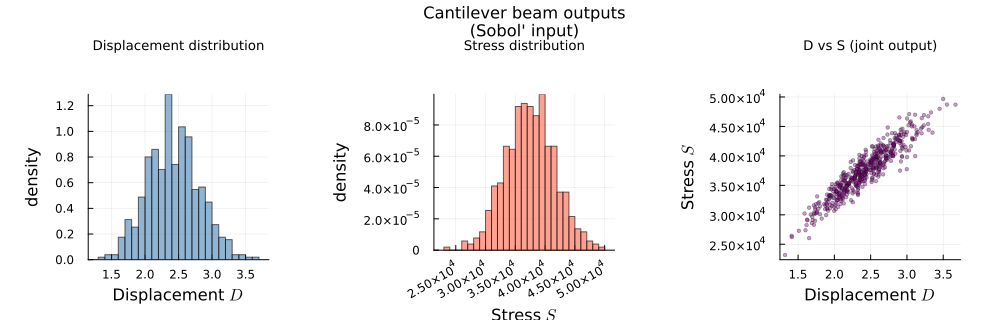

In [7]:
if HAVE_PLOTS
    # Sample cantilever beam inputs & outputs
    n_b = 512
    dd_b = DigitalNetB2(3; seed=7)
    tm_b = Gaussian(dd_b; mean=[2.9e7, 500.0, 1000.0],
                   covariance=Diagonal([(0.058e7)^2, 100.0^2, 100.0^2]))
    x_b = gen_samples(dd_b, n_b)
    xt_b = transform(tm_b, x_b)
    y_b = hcat([cantilever_beam(xt_b[i, :]) for i in 1:n_b]...)'  # n_b × 2

    p1 = histogram(y_b[:, 1]; bins=40, normalize=:pdf,
        alpha=0.6, color=:steelblue, label=nothing,
        xlabel="Displacement \$D\$", ylabel="density", title="Displacement distribution")
    p2 = histogram(y_b[:, 2]; bins=40, normalize=:pdf,
        alpha=0.6, color=:tomato, label=nothing,
        xlabel="Stress \$S\$", ylabel="density", title="Stress distribution",
        xrotation=30)
    p3 = scatter(y_b[:, 1], y_b[:, 2];
        markersize=2, alpha=0.4, color=:purple, label=nothing,
        xlabel="Displacement \$D\$", ylabel="Stress \$S\$",
        title="D vs S (joint output)")

    display(plot(p1, p2, p3; layout=(1, 3), size=(1000, 320),
        plot_titlevspan=0.12, plot_title="Cantilever beam outputs\n(Sobol' input)",
        top_margin=10Plots.mm, bottom_margin=8Plots.mm, left_margin=10Plots.mm))
end
